# JPY/USD Suggestion Agent (Daily)

このノートブックは以下を実行します。
- USDJPY= の日足データ取得
- 特徴量作成と時系列分割による学習
- BUY確率の推定
- BUY/HOLD/SELL の提案
- 最大損失ルールを含む簡易バックテスト

初期設計:
- 予測対象: 翌日方向
- モデル: LightGBM (未導入時は自動でGradientBoostingにフォールバック)
- HOLD必須: 低確信度帯は見送り

In [44]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from datetime import datetime
import json
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score, brier_score_loss
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.calibration import calibration_curve

try:
    import lightgbm as lgb
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

DATA_DIR = Path("data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
CSV_PATH = DATA_DIR / "usdjpy_daily.csv"

RANDOM_STATE = 42
BUY_THRESHOLD = 0.55
SELL_THRESHOLD = 0.45
STOP_LOSS = -0.02

# Order engine defaults (ATR-based)
ORDER_ATR_PERIOD = 14
ORDER_ENTRY_OFFSET_ATR = 0.25
ORDER_TP_ATR_MULT = 1.5
ORDER_SL_ATR_MULT = 1.0
ORDER_PRICE_ROUND = 3

# Order selection mode
# auto: model/reliability driven, manual: user-selected order type and prices
ORDER_SELECTION_MODE = "auto"
MANUAL_ORDER_TYPE = "IFDOCO"  # MARKET/LIMIT/STOP/IFD/OCO/IFDOCO
MANUAL_ORDER_SIDE = "BUY"      # BUY/SELL
MANUAL_ENTRY_PRICE = None       # e.g. 158.250
MANUAL_TP_PRICE = None          # e.g. 159.100
MANUAL_SL_PRICE = None          # e.g. 157.800

BASE_FEATURE_COLS = [
    "ret_1", "ret_3", "ret_5",
    "ret_1_lag1", "ret_1_lag2", "ret_1_lag3", "ret_1_lag5", "ret_1_lag10",
    "ma_gap_5", "ma_gap_20", "vol_5", "vol_20", "hl_range",
]

RARITY_FEATURE_COLS = [
    "ret_1_z20", "close_pos_20", "is_vol_spike", "gap_open",
]

MACRO_CORE_COLS = [
    "dff_lag1", "dgs10_lag1", "dgs2_lag1", "t10yie_lag1", "vixcls_lag1", "dtwexbgs_lag1",
    "slope_10y2y_lag1", "slope_10ypolicy_lag1", "real_rate_proxy_lag1",
]

MACRO_PRED_COLS = [
    "slope_10y2y_pred1", "slope_10ypolicy_pred1", "real_rate_proxy_pred1", "vixcls_pred1",
]

TENY_FEATURE_COLS = [
    "dgs10_chg1_lag1", "dgs10_chg5_lag1", "dgs10_z20_lag1",
    "us10y_yf_lag1", "us_yield_curve_yf_lag1", "us10y_fred_yf_gap_lag1",
]

CROSS_ASSET_COLS = [
    "gold_ret5_lag1", "oil_ret5_lag1", "spx_ret5_lag1", "nikkei_ret5_lag1", "dxy_yf_ret5_lag1",
]

EVENT_SURPRISE_COLS = [
    "cpi_surprise", "cpi_surprise_decay", "cpi_event_gap",
    "payems_surprise", "payems_surprise_decay", "payems_event_gap",
    "unrate_surprise", "unrate_surprise_decay", "unrate_event_gap",
    "dff_surprise", "dff_surprise_decay", "dff_event_gap",
]

print("LightGBM available:", HAS_LGBM)
print("Data path:", CSV_PATH.resolve())
print("Order mode:", ORDER_SELECTION_MODE, "| manual type:", MANUAL_ORDER_TYPE)

LightGBM available: True
Data path: /Users/tsukasahamaoka/Document/DS_Projects/2_PR,TS_FX forcast/data/usdjpy_daily.csv
Order mode: auto | manual type: IFDOCO


In [45]:
def download_usdjpy(period="10y", interval="1d"):
    tickers = ["JPY=X", "USDJPY=X", "USDJPY="]
    df = pd.DataFrame()
    used_ticker = None

    for t in tickers:
        tmp = yf.download(t, period=period, interval=interval, auto_adjust=False, progress=False)
        if len(tmp) > 0:
            df = tmp
            used_ticker = t
            break

    if len(df) == 0:
        raise ValueError("FXデータ取得に失敗しました。ネットワークまたはティッカーを確認してください。")

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [c[0] for c in df.columns]

    df = df.reset_index().rename(columns=str)
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])
        df = df.sort_values("Date").drop_duplicates(subset=["Date"]).set_index("Date")

    df = df[["Open", "High", "Low", "Close", "Volume"]].copy()
    df.to_csv(CSV_PATH)
    print("ticker:", used_ticker)
    return df

raw_df = download_usdjpy(period="10y", interval="1d")
print(raw_df.shape)
raw_df.tail(3)

ticker: JPY=X
(2602, 5)


,Open,High,Low,Close,Volume
Date,,,,,
2026-04-08,158.647995,158.746994,157.893005,158.716003,0
2026-04-09,158.634003,159.279999,158.634003,158.641998,0
2026-04-10,158.960007,159.373993,158.848007,159.156998,0


In [46]:
def fetch_fred_series(series_id, start_date, end_date):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    s = pd.read_csv(url)
    s.columns = ["Date", series_id]
    s["Date"] = pd.to_datetime(s["Date"])
    s[series_id] = pd.to_numeric(s[series_id], errors="coerce")
    s = s.set_index("Date").sort_index()
    s = s.loc[(s.index >= pd.to_datetime(start_date)) & (s.index <= pd.to_datetime(end_date))]
    return s


def fetch_yf_close_series(ticker, start_date, end_date, out_name):
    df = yf.download(ticker, start=start_date, end=end_date, interval="1d", auto_adjust=False, progress=False)
    if len(df) == 0:
        return None
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [c[0] for c in df.columns]
    if "Close" not in df.columns:
        return None
    s = df[["Close"]].rename(columns={"Close": out_name}).copy()
    s.index = pd.to_datetime(s.index)
    return s


def build_macro_panel(price_index):
    start_date = price_index.min().date().isoformat()
    end_date = price_index.max().date().isoformat()

    fred_ids = [
        "DFF", "DGS10", "DGS2", "T10YIE", "VIXCLS", "DTWEXBGS",
        "UNRATE", "GDP", "DGS30", "DGS5", "T5YIE", "CPIAUCSL", "PAYEMS",
    ]

    panel = pd.DataFrame(index=price_index)
    for sid in fred_ids:
        try:
            s = fetch_fred_series(sid, start_date, end_date)
            panel = panel.join(s.rename(columns={sid: sid.lower()}), how="left")
        except Exception as e:
            print(f"skip {sid}: {e}")

    # Additional market features from yfinance
    yf_map = {
        "^TNX": "us10y_yf",
        "^FVX": "us5y_yf",
        "^IRX": "us3m_yf",
        "GC=F": "gold_close",
        "CL=F": "oil_close",
        "^GSPC": "spx_close",
        "^N225": "nikkei_close",
        "DX-Y.NYB": "dxy_yf_close",
    }

    for ticker, out_name in yf_map.items():
        try:
            s = fetch_yf_close_series(ticker, start_date, end_date, out_name)
            if s is not None:
                panel = panel.join(s, how="left")
        except Exception as e:
            print(f"skip {ticker}: {e}")

    panel = panel.sort_index().ffill()
    panel.to_csv(DATA_DIR / "macro_panel_fred.csv")
    return panel


macro_panel = build_macro_panel(raw_df.index)
print("macro panel shape:", macro_panel.shape)
print("macro columns:", list(macro_panel.columns))
macro_panel.tail(3)

macro panel shape: (2602, 21)
macro columns: ['dff', 'dgs10', 'dgs2', 't10yie', 'vixcls', 'dtwexbgs', 'unrate', 'gdp', 'dgs30', 'dgs5', 't5yie', 'cpiaucsl', 'payems', 'us10y_yf', 'us5y_yf', 'us3m_yf', 'gold_close', 'oil_close', 'spx_close', 'nikkei_close', 'dxy_yf_close']


,dff,dgs10,dgs2,t10yie,vixcls,dtwexbgs,unrate,gdp,dgs30,dgs5,...,cpiaucsl,payems,us10y_yf,us5y_yf,us3m_yf,gold_close,oil_close,spx_close,nikkei_close,dxy_yf_close
Date,,,,,,,,,,,,,,,,,,,,,
2026-04-08,3.64,4.29,3.79,2.33,21.04,120.6565,4.4,31422.526,4.89,3.92,...,326.031,158432.0,4.291,3.920,3.600,4749.500000,94.410004,6782.810059,56308.421875,99.129997
2026-04-09,3.64,4.29,3.79,2.34,19.49,120.6565,4.4,31422.526,4.89,3.92,...,326.031,158432.0,4.293,3.915,3.588,4792.200195,97.870003,6824.660156,55895.320312,98.820000
2026-04-10,3.64,4.29,3.79,2.34,19.49,120.6565,4.4,31422.526,4.89,3.92,...,326.031,158432.0,4.293,3.915,3.588,4792.200195,97.870003,6824.660156,55895.320312,98.820000


In [47]:
def build_features(df, macro_df):
    x = df.copy()

    x["ret_1"] = x["Close"].pct_change(1)
    x["ret_3"] = x["Close"].pct_change(3)
    x["ret_5"] = x["Close"].pct_change(5)

    for lag in [1, 2, 3, 5, 10]:
        x[f"ret_1_lag{lag}"] = x["ret_1"].shift(lag)

    x["ma_5"] = x["Close"].rolling(5).mean()
    x["ma_20"] = x["Close"].rolling(20).mean()
    x["ma_gap_5"] = x["Close"] / x["ma_5"] - 1
    x["ma_gap_20"] = x["Close"] / x["ma_20"] - 1

    x["vol_5"] = x["ret_1"].rolling(5).std()
    x["vol_20"] = x["ret_1"].rolling(20).std()
    x["hl_range"] = (x["High"] - x["Low"]) / x["Close"]

    # Rarity / anomaly features (delay-safe)
    x["ret_1_z20"] = (x["ret_1"] - x["ret_1"].rolling(20).mean()) / (x["ret_1"].rolling(20).std() + 1e-9)
    x["close_pos_20"] = (x["Close"] - x["Close"].rolling(20).min()) / (
        (x["Close"].rolling(20).max() - x["Close"].rolling(20).min()) + 1e-9
    )
    x["vol_5_q75_20"] = x["vol_5"].rolling(20).quantile(0.75)
    x["is_vol_spike"] = (x["vol_5"] > x["vol_5_q75_20"]).astype(int)
    x["gap_open"] = (x["Open"] - x["Close"].shift(1)) / (x["Close"].shift(1) + 1e-9)

    mx = macro_df.copy()
    x = x.join(mx, how="left")

    def col(name):
        return x[name] if name in x.columns else pd.Series(np.nan, index=x.index)

    def add_event_surprise_features(frame, src_col, out_prefix, exp_window=63, decay_half_life=7):
        if src_col not in frame.columns:
            frame[f"{out_prefix}_surprise"] = np.nan
            frame[f"{out_prefix}_surprise_decay"] = np.nan
            frame[f"{out_prefix}_event_gap"] = np.nan
            return

        raw = frame[src_col].copy()
        expected = raw.shift(1).rolling(exp_window, min_periods=20).mean()
        is_event = raw.notna() & raw.shift(1).notna() & (raw != raw.shift(1))

        surprise_event = (raw - expected).where(is_event)
        surprise_daily = surprise_event.ffill()

        event_idx = np.where(is_event.values, np.arange(len(frame)), np.nan)
        event_idx = pd.Series(event_idx, index=frame.index).ffill()
        days_since = pd.Series(np.arange(len(frame)), index=frame.index) - event_idx
        no_event_mask = event_idx.isna()
        days_since = days_since.mask(no_event_mask, np.nan)

        decay_weight = np.exp(-np.log(2) * days_since.fillna(0) / decay_half_life)
        decay_weight = decay_weight.mask(no_event_mask, 0.0)

        frame[f"{out_prefix}_surprise"] = surprise_daily.shift(1)
        frame[f"{out_prefix}_surprise_decay"] = (surprise_daily * decay_weight).shift(1)
        frame[f"{out_prefix}_event_gap"] = days_since.shift(1)

    # Daily-safe macro core (1-day lag)
    x["dff_lag1"] = col("dff").shift(1)
    x["dgs10_lag1"] = col("dgs10").shift(1)
    x["dgs2_lag1"] = col("dgs2").shift(1)
    x["t10yie_lag1"] = col("t10yie").shift(1)
    x["vixcls_lag1"] = col("vixcls").shift(1)
    x["dtwexbgs_lag1"] = col("dtwexbgs").shift(1)

    x["slope_10y2y_lag1"] = x["dgs10_lag1"] - x["dgs2_lag1"]
    x["slope_10ypolicy_lag1"] = x["dgs10_lag1"] - x["dff_lag1"]
    x["real_rate_proxy_lag1"] = x["dgs10_lag1"] - x["t10yie_lag1"]

    # 10Y-yield-focused extra features
    x["dgs10_chg1_lag1"] = col("dgs10").diff(1).shift(1)
    x["dgs10_chg5_lag1"] = col("dgs10").diff(5).shift(1)
    x["dgs10_z20_lag1"] = ((col("dgs10") - col("dgs10").rolling(20).mean()) / (col("dgs10").rolling(20).std() + 1e-9)).shift(1)

    x["us10y_yf_lag1"] = col("us10y_yf").shift(1)
    x["us_yield_curve_yf_lag1"] = (col("us10y_yf") - col("us3m_yf")).shift(1)
    x["us10y_fred_yf_gap_lag1"] = (col("dgs10") - col("us10y_yf")).shift(1)

    # Cross-asset context features (lag-safe)
    x["gold_ret5_lag1"] = col("gold_close").pct_change(5).shift(1)
    x["oil_ret5_lag1"] = col("oil_close").pct_change(5).shift(1)
    x["spx_ret5_lag1"] = col("spx_close").pct_change(5).shift(1)
    x["nikkei_ret5_lag1"] = col("nikkei_close").pct_change(5).shift(1)
    x["dxy_yf_ret5_lag1"] = col("dxy_yf_close").pct_change(5).shift(1)

    # Event surprise features (continuous, non-dummy, delay-safe)
    add_event_surprise_features(x, "cpiaucsl", "cpi")
    add_event_surprise_features(x, "payems", "payems")
    add_event_surprise_features(x, "unrate", "unrate")
    add_event_surprise_features(x, "dff", "dff")

    # 1-step forecast of selected macro features (persistence + short trend)
    x["slope_10y2y_pred1"] = x["slope_10y2y_lag1"].rolling(5, min_periods=3).mean().shift(1)
    x["slope_10ypolicy_pred1"] = x["slope_10ypolicy_lag1"].rolling(5, min_periods=3).mean().shift(1)
    x["real_rate_proxy_pred1"] = x["real_rate_proxy_lag1"].rolling(5, min_periods=3).mean().shift(1)
    x["vixcls_pred1"] = x["vixcls_lag1"].rolling(3, min_periods=2).mean().shift(1)

    x["target_buy"] = (x["Close"].shift(-1) > x["Close"]).astype(int)

    all_candidate_cols = (
        BASE_FEATURE_COLS + RARITY_FEATURE_COLS + MACRO_CORE_COLS + MACRO_PRED_COLS +
        TENY_FEATURE_COLS + CROSS_ASSET_COLS + EVENT_SURPRISE_COLS
    )
    feature_cols = [c for c in all_candidate_cols if c in x.columns]

    out = x[feature_cols + ["target_buy", "Close"]].dropna().copy()
    return out, feature_cols


feat_df, feature_cols = build_features(raw_df, macro_panel)
print("rows:", feat_df.shape[0], "features:", len(feature_cols))
print("10Y-related available:", [c for c in TENY_FEATURE_COLS if c in feature_cols])
print("event-surprise available:", [c for c in EVENT_SURPRISE_COLS if c in feature_cols])
feat_df.head(3)

rows: 2542 features: 53
10Y-related available: ['dgs10_chg1_lag1', 'dgs10_chg5_lag1', 'dgs10_z20_lag1', 'us10y_yf_lag1', 'us_yield_curve_yf_lag1', 'us10y_fred_yf_gap_lag1']
event-surprise available: ['cpi_surprise', 'cpi_surprise_decay', 'cpi_event_gap', 'payems_surprise', 'payems_surprise_decay', 'payems_event_gap', 'unrate_surprise', 'unrate_surprise_decay', 'unrate_event_gap', 'dff_surprise', 'dff_surprise_decay', 'dff_event_gap']


,ret_1,ret_3,ret_5,ret_1_lag1,ret_1_lag2,ret_1_lag3,ret_1_lag5,ret_1_lag10,ma_gap_5,ma_gap_20,...,payems_surprise_decay,payems_event_gap,unrate_surprise,unrate_surprise_decay,unrate_event_gap,dff_surprise,dff_surprise_decay,dff_event_gap,target_buy,Close
Date,,,,,,,,,,,,,,,,,,,,,
2016-07-04,-0.005676,-0.002074,0.003535,0.002870,0.000750,0.008732,-0.026398,-0.000907,-0.000803,-0.021893,...,373.000000,0.0,-0.1,-0.100000,0.0,0.040000,0.040000,0.0,1,102.487999
2016-07-05,0.000293,-0.002530,0.006934,-0.005676,0.002870,0.000750,-0.003084,-0.007874,-0.001885,-0.019304,...,337.834927,1.0,-0.1,-0.090572,1.0,0.040000,0.036229,1.0,0,102.517998
2016-07-06,-0.013432,-0.018744,-0.015190,0.000293,-0.005676,0.002870,0.008732,0.008148,-0.012291,-0.029639,...,305.985088,2.0,-0.1,-0.082034,2.0,0.028689,0.028689,0.0,1,101.140999


In [48]:
split_idx = int(len(feat_df) * 0.8)
train_df = feat_df.iloc[:split_idx].copy()
valid_df = feat_df.iloc[split_idx:].copy()

X_train = train_df[feature_cols]
y_train = train_df["target_buy"]
X_valid = valid_df[feature_cols]
y_valid = valid_df["target_buy"]

print("train period:", train_df.index.min().date(), "->", train_df.index.max().date(), "rows=", len(train_df))
print("valid period:", valid_df.index.min().date(), "->", valid_df.index.max().date(), "rows=", len(valid_df))

if HAS_LGBM:
    model = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="binary_logloss",
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)],
    )
else:
    model = GradientBoostingClassifier(random_state=RANDOM_STATE)
    model.fit(X_train, y_train)

proba_valid = model.predict_proba(X_valid)[:, 1]
pred_valid = (proba_valid >= 0.5).astype(int)

print("AUC:", round(roc_auc_score(y_valid, proba_valid), 4))
print("LogLoss:", round(log_loss(y_valid, proba_valid), 4))
print("Accuracy@0.5:", round(accuracy_score(y_valid, pred_valid), 4))

train period: 2016-07-04 -> 2024-04-22 rows= 2033
valid period: 2024-04-23 -> 2026-04-10 rows= 509
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[2]	valid_0's binary_logloss: 0.692378
AUC: 0.4766
LogLoss: 0.6924
Accuracy@0.5: 0.5265


In [49]:
def to_action(prob_buy, buy_th=BUY_THRESHOLD, sell_th=SELL_THRESHOLD):
    if prob_buy >= buy_th:
        return "BUY"
    if prob_buy <= sell_th:
        return "SELL"
    return "HOLD"


def apply_stop_loss(prev_position, daily_return, stop_loss=STOP_LOSS):
    # 含み損が閾値を超えたら次日にポジションを閉じる
    if prev_position == 1 and daily_return <= stop_loss:
        return 0
    if prev_position == -1 and (-daily_return) <= stop_loss:
        return 0
    return prev_position


def backtest_three_actions(df_part, prob, buy_th=BUY_THRESHOLD, sell_th=SELL_THRESHOLD, stop_loss=STOP_LOSS):
    bt = df_part.copy()
    bt = bt.assign(prob_buy=prob)
    bt["signal"] = bt["prob_buy"].apply(lambda p: to_action(p, buy_th, sell_th))

    # BUY=1, SELL=-1, HOLD=0
    pos_map = {"BUY": 1, "SELL": -1, "HOLD": 0}
    bt["position_raw"] = bt["signal"].map(pos_map).astype(int)

    bt["ret_next"] = bt["Close"].pct_change().shift(-1)
    bt["position"] = bt["position_raw"].copy()

    for i in range(1, len(bt)):
        prev_pos = int(bt.iloc[i - 1]["position"])
        prev_ret = bt.iloc[i - 1]["ret_next"]
        desired_pos = int(bt.iloc[i]["position_raw"])

        if pd.notna(prev_ret):
            risk_adjusted = apply_stop_loss(prev_pos, prev_ret, stop_loss)
            if risk_adjusted == 0 and prev_pos != 0:
                bt.iloc[i, bt.columns.get_loc("position")] = 0
            else:
                bt.iloc[i, bt.columns.get_loc("position")] = desired_pos
        else:
            bt.iloc[i, bt.columns.get_loc("position")] = desired_pos

    bt["strategy_ret"] = bt["position"] * bt["ret_next"]
    bt = bt.dropna(subset=["strategy_ret"]).copy()

    ann_factor = np.sqrt(252)
    mean_ret = bt["strategy_ret"].mean()
    std_ret = bt["strategy_ret"].std()
    sharpe = (mean_ret / std_ret * ann_factor) if std_ret > 0 else 0.0

    equity = (1 + bt["strategy_ret"]).cumprod()
    rolling_max = equity.cummax()
    drawdown = equity / rolling_max - 1

    metrics = {
        "cumulative_return": float(equity.iloc[-1] - 1),
        "sharpe": float(sharpe),
        "max_drawdown": float(drawdown.min()),
        "trade_count": int((bt["signal"] != "HOLD").sum()),
    }
    return bt, metrics

In [50]:
valid_bt, trade_metrics = backtest_three_actions(
    valid_df,
    proba_valid,
    buy_th=BUY_THRESHOLD,
    sell_th=SELL_THRESHOLD,
    stop_loss=STOP_LOSS,
)

print("Trade Metrics")
for k, v in trade_metrics.items():
    print(f"{k}: {v:.6f}" if isinstance(v, float) else f"{k}: {v}")

valid_bt[["Close", "prob_buy", "signal", "position", "strategy_ret"]].tail(10)

Trade Metrics
cumulative_return: 0.000000
sharpe: 0.000000
max_drawdown: 0.000000
trade_count: 0


,Close,prob_buy,signal,position,strategy_ret
Date,,,,,
2026-03-27,159.703995,0.529304,HOLD,0,0.0
2026-03-30,160.233994,0.538449,HOLD,0,-0.0
2026-03-31,159.841003,0.530324,HOLD,0,-0.0
2026-04-01,158.578995,0.530324,HOLD,0,0.0
2026-04-02,158.688004,0.523925,HOLD,0,0.0
2026-04-03,159.490997,0.523014,HOLD,0,0.0
2026-04-06,159.779999,0.529304,HOLD,0,-0.0
2026-04-07,159.682999,0.530324,HOLD,0,-0.0
2026-04-08,158.716003,0.520490,HOLD,0,-0.0


In [51]:
def suggest_latest_action(raw_price_df, macro_df, model, feature_cols, buy_th=BUY_THRESHOLD, sell_th=SELL_THRESHOLD):
    feat_all, _ = build_features(raw_price_df, macro_df)
    latest = feat_all.iloc[[-1]].copy()
    p = float(model.predict_proba(latest[feature_cols])[:, 1][0])
    action = to_action(p, buy_th, sell_th)

    return {
        "date": str(latest.index[0].date()),
        "prob_buy": p,
        "action": action,
        "buy_threshold": buy_th,
        "sell_threshold": sell_th,
    }

result = suggest_latest_action(raw_df, macro_panel, model, feature_cols)
print("Latest Suggestion")
for k, v in result.items():
    print(f"{k}: {v}")

Latest Suggestion
date: 2026-04-10
prob_buy: 0.5293039402297798
action: HOLD
buy_threshold: 0.55
sell_threshold: 0.45


In [52]:
rows = []
for sell_th in np.arange(0.35, 0.51, 0.02):
    for buy_th in np.arange(0.49, 0.71, 0.02):
        if buy_th <= sell_th:
            continue
        _, m = backtest_three_actions(valid_df, proba_valid, buy_th=buy_th, sell_th=sell_th, stop_loss=STOP_LOSS)
        rows.append({"sell_th": round(float(sell_th), 2), "buy_th": round(float(buy_th), 2), **m})

th_df = pd.DataFrame(rows).sort_values(["sharpe", "cumulative_return"], ascending=False)
th_df.head(10)

,sell_th,buy_th,cumulative_return,sharpe,max_drawdown,trade_count
0,0.35,0.49,0.03563,0.221703,-0.130734,508
1,0.35,0.51,0.03563,0.221703,-0.130734,508
11,0.37,0.49,0.03563,0.221703,-0.130734,508
12,0.37,0.51,0.03563,0.221703,-0.130734,508
22,0.39,0.49,0.03563,0.221703,-0.130734,508
23,0.39,0.51,0.03563,0.221703,-0.130734,508
33,0.41,0.49,0.03563,0.221703,-0.130734,508
34,0.41,0.51,0.03563,0.221703,-0.130734,508
44,0.43,0.49,0.03563,0.221703,-0.130734,508
45,0.43,0.51,0.03563,0.221703,-0.130734,508


In [53]:
def cv_compare_feature_sets(df, base_cols, ext_cols, target_col="target_buy", n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)

    def _fit_predict(train_x, train_y, valid_x):
        if HAS_LGBM:
            m = lgb.LGBMClassifier(
                n_estimators=250,
                learning_rate=0.03,
                num_leaves=31,
                subsample=0.9,
                colsample_bytree=0.9,
                random_state=RANDOM_STATE,
                verbose=-1,
            )
        else:
            m = GradientBoostingClassifier(random_state=RANDOM_STATE)
        m.fit(train_x, train_y)
        return m.predict_proba(valid_x)[:, 1]

    records = []
    for name, cols in [("base", base_cols), ("extended", ext_cols)]:
        for fold, (tr_idx, va_idx) in enumerate(tscv.split(df), start=1):
            tr = df.iloc[tr_idx]
            va = df.iloc[va_idx]
            pred = _fit_predict(tr[cols], tr[target_col], va[cols])
            auc = roc_auc_score(va[target_col], pred)
            ll = log_loss(va[target_col], pred)
            records.append({"set": name, "fold": fold, "auc": auc, "logloss": ll})

    cv_df = pd.DataFrame(records)
    summary = cv_df.groupby("set", as_index=False).agg(
        auc_mean=("auc", "mean"),
        auc_std=("auc", "std"),
        logloss_mean=("logloss", "mean"),
        logloss_std=("logloss", "std"),
    )
    return cv_df, summary

cv_detail, cv_summary = cv_compare_feature_sets(feat_df, BASE_FEATURE_COLS, feature_cols)
comparison = cv_summary.pivot_table(index=None, columns="set")

print("CV Summary")
cv_summary

CV Summary


,set,auc_mean,auc_std,logloss_mean,logloss_std
0,base,0.505838,0.030833,0.795954,0.057391
1,extended,0.505436,0.021656,0.823969,0.053090


In [54]:
def cv_compare_multiple_sets(df, feature_sets, target_col="target_buy", n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)

    def _fit_predict(train_x, train_y, valid_x):
        if HAS_LGBM:
            m = lgb.LGBMClassifier(
                n_estimators=250,
                learning_rate=0.03,
                num_leaves=31,
                subsample=0.9,
                colsample_bytree=0.9,
                random_state=RANDOM_STATE,
                verbose=-1,
            )
        else:
            m = GradientBoostingClassifier(random_state=RANDOM_STATE)
        m.fit(train_x, train_y)
        return m.predict_proba(valid_x)[:, 1]

    records = []
    for set_name, cols in feature_sets.items():
        use_cols = [c for c in cols if c in df.columns]
        for fold, (tr_idx, va_idx) in enumerate(tscv.split(df), start=1):
            tr = df.iloc[tr_idx]
            va = df.iloc[va_idx]
            pred = _fit_predict(tr[use_cols], tr[target_col], va[use_cols])
            records.append({
                "set": set_name,
                "fold": fold,
                "n_features": len(use_cols),
                "auc": roc_auc_score(va[target_col], pred),
                "logloss": log_loss(va[target_col], pred),
            })

    detail = pd.DataFrame(records)
    summary = detail.groupby("set", as_index=False).agg(
        n_features=("n_features", "max"),
        auc_mean=("auc", "mean"),
        auc_std=("auc", "std"),
        logloss_mean=("logloss", "mean"),
        logloss_std=("logloss", "std"),
    ).sort_values("auc_mean", ascending=False)
    return detail, summary


feature_sets = {
    "tech_only": BASE_FEATURE_COLS + RARITY_FEATURE_COLS,
    "tech_plus_macro": BASE_FEATURE_COLS + RARITY_FEATURE_COLS + MACRO_CORE_COLS,
    "tech_macro_10y": BASE_FEATURE_COLS + RARITY_FEATURE_COLS + MACRO_CORE_COLS + TENY_FEATURE_COLS,
    "tech_macro_10y_cross": BASE_FEATURE_COLS + RARITY_FEATURE_COLS + MACRO_CORE_COLS + TENY_FEATURE_COLS + CROSS_ASSET_COLS,
    "tech_macro_event": BASE_FEATURE_COLS + RARITY_FEATURE_COLS + MACRO_CORE_COLS + TENY_FEATURE_COLS + EVENT_SURPRISE_COLS,
    "tech_macro_10y_cross_event": BASE_FEATURE_COLS + RARITY_FEATURE_COLS + MACRO_CORE_COLS + TENY_FEATURE_COLS + CROSS_ASSET_COLS + EVENT_SURPRISE_COLS,
    "tech_macro_all": BASE_FEATURE_COLS + RARITY_FEATURE_COLS + MACRO_CORE_COLS + TENY_FEATURE_COLS + CROSS_ASSET_COLS + MACRO_PRED_COLS + EVENT_SURPRISE_COLS,
}

multi_cv_detail, multi_cv_summary = cv_compare_multiple_sets(feat_df, feature_sets)
print("Macro + 10Y + cross-asset + event-surprise CV comparison")
multi_cv_summary

Macro + 10Y + cross-asset + event-surprise CV comparison


,set,n_features,auc_mean,auc_std,logloss_mean,logloss_std
1,tech_macro_10y_cross,37,0.518427,0.022936,0.808399,0.098216
6,tech_plus_macro,26,0.508509,0.016835,0.801608,0.070564
3,tech_macro_all,53,0.507891,0.011698,0.825118,0.057248
0,tech_macro_10y,32,0.504995,0.016640,0.824821,0.082086
2,tech_macro_10y_cross_event,49,0.504919,0.015050,0.820516,0.043821
5,tech_only,17,0.504419,0.026003,0.803171,0.070783
4,tech_macro_event,44,0.498385,0.028811,0.837736,0.048348


In [55]:
def fit_model(train_x, train_y):
    if HAS_LGBM:
        m = lgb.LGBMClassifier(
            n_estimators=300,
            learning_rate=0.03,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=RANDOM_STATE,
            verbose=-1,
        )
    else:
        m = GradientBoostingClassifier(random_state=RANDOM_STATE)
    m.fit(train_x, train_y)
    return m


def cv_metrics_for_cols(df, cols, target_col="target_buy", n_splits=5):
    use_cols = [c for c in cols if c in df.columns]
    tscv = TimeSeriesSplit(n_splits=n_splits)
    rows = []
    for fold, (tr_idx, va_idx) in enumerate(tscv.split(df), start=1):
        tr = df.iloc[tr_idx]
        va = df.iloc[va_idx]
        m = fit_model(tr[use_cols], tr[target_col])
        p = m.predict_proba(va[use_cols])[:, 1]
        rows.append({
            "fold": fold,
            "auc": roc_auc_score(va[target_col], p),
            "logloss": log_loss(va[target_col], p),
        })
    fold_df = pd.DataFrame(rows)
    return fold_df, {
        "n_features": len(use_cols),
        "auc_mean": float(fold_df["auc"].mean()),
        "auc_std": float(fold_df["auc"].std()),
        "logloss_mean": float(fold_df["logloss"].mean()),
        "logloss_std": float(fold_df["logloss"].std()),
    }


best_set_name = multi_cv_summary.iloc[0]["set"]
best_cols = [c for c in feature_sets[best_set_name] if c in feat_df.columns]
print("Best feature set:", best_set_name, "n=", len(best_cols))

group_map = {
    "base_tech": BASE_FEATURE_COLS + RARITY_FEATURE_COLS,
    "macro_core": MACRO_CORE_COLS,
    "teny": TENY_FEATURE_COLS,
    "cross_asset": CROSS_ASSET_COLS,
    "macro_pred": MACRO_PRED_COLS,
    "event_surprise": EVENT_SURPRISE_COLS,
}

# Group drop ablation under identical CV splits
baseline_fold, baseline_stat = cv_metrics_for_cols(feat_df, best_cols)
ablation_rows = [{
    "group": "baseline",
    "n_features": baseline_stat["n_features"],
    "auc_mean": baseline_stat["auc_mean"],
    "logloss_mean": baseline_stat["logloss_mean"],
    "delta_auc": 0.0,
    "delta_logloss": 0.0,
}]

for g, cols in group_map.items():
    drop_cols = [c for c in cols if c in best_cols]
    if len(drop_cols) == 0:
        continue
    remain_cols = [c for c in best_cols if c not in drop_cols]
    _, stat = cv_metrics_for_cols(feat_df, remain_cols)
    ablation_rows.append({
        "group": f"drop_{g}",
        "n_features": stat["n_features"],
        "auc_mean": stat["auc_mean"],
        "logloss_mean": stat["logloss_mean"],
        "delta_auc": stat["auc_mean"] - baseline_stat["auc_mean"],
        "delta_logloss": stat["logloss_mean"] - baseline_stat["logloss_mean"],
    })

ablation_df = pd.DataFrame(ablation_rows).sort_values("delta_auc")
print("Group-drop ablation (negative delta_auc means the dropped group was useful)")
display(ablation_df)

# Grouped permutation importance on current holdout
X_train_best = train_df[best_cols]
y_train_best = train_df["target_buy"]
X_valid_best = valid_df[best_cols]
y_valid_best = valid_df["target_buy"]
perm_model = fit_model(X_train_best, y_train_best)
base_prob = perm_model.predict_proba(X_valid_best)[:, 1]
base_auc = roc_auc_score(y_valid_best, base_prob)
base_ll = log_loss(y_valid_best, base_prob)

perm_rows = []
rng = np.random.default_rng(RANDOM_STATE)
for g, cols in group_map.items():
    grp_cols = [c for c in cols if c in best_cols]
    if len(grp_cols) == 0:
        continue

    auc_drops, ll_incs = [], []
    for _ in range(5):
        Xp = X_valid_best.copy()
        perm_idx = rng.permutation(len(Xp))
        Xp.loc[:, grp_cols] = Xp[grp_cols].iloc[perm_idx].to_numpy()
        prob_p = perm_model.predict_proba(Xp)[:, 1]
        auc_drops.append(base_auc - roc_auc_score(y_valid_best, prob_p))
        ll_incs.append(log_loss(y_valid_best, prob_p) - base_ll)

    perm_rows.append({
        "group": g,
        "auc_drop_mean": float(np.mean(auc_drops)),
        "auc_drop_std": float(np.std(auc_drops)),
        "logloss_increase_mean": float(np.mean(ll_incs)),
        "logloss_increase_std": float(np.std(ll_incs)),
    })

perm_group_df = pd.DataFrame(perm_rows).sort_values("auc_drop_mean", ascending=False)
print("Grouped permutation importance on holdout")
display(perm_group_df)

multi_cv_summary.to_csv(DATA_DIR / "feature_set_cv_summary.csv", index=False)
ablation_df.to_csv(DATA_DIR / "group_drop_ablation.csv", index=False)
perm_group_df.to_csv(DATA_DIR / "group_permutation_importance.csv", index=False)
print("saved:", DATA_DIR / "feature_set_cv_summary.csv")
print("saved:", DATA_DIR / "group_drop_ablation.csv")
print("saved:", DATA_DIR / "group_permutation_importance.csv")

Best feature set: tech_macro_10y_cross n= 37
Group-drop ablation (negative delta_auc means the dropped group was useful)


,group,n_features,auc_mean,logloss_mean,delta_auc,delta_logloss
1,drop_base_tech,20,0.497437,0.828069,-0.020030,-0.008103
4,drop_cross_asset,32,0.504700,0.858036,-0.012767,0.021864
2,drop_macro_core,28,0.510535,0.832581,-0.006932,-0.003591
0,baseline,37,0.517467,0.836172,0.000000,0.000000
3,drop_teny,31,0.520390,0.825396,0.002923,-0.010776


Grouped permutation importance on holdout


,group,auc_drop_mean,auc_drop_std,logloss_increase_mean,logloss_increase_std
0,base_tech,0.037914,0.013752,0.030973,0.008469
2,teny,0.014095,0.008593,0.010272,0.004990
1,macro_core,0.005159,0.003518,0.001116,0.002739
3,cross_asset,0.001836,0.011042,0.001748,0.010186


saved: data/feature_set_cv_summary.csv
saved: data/group_drop_ablation.csv
saved: data/group_permutation_importance.csv


In [56]:
# Fold stability check for group-drop ablation
fold_delta_rows = []
baseline_fold_use = baseline_fold[["fold", "auc", "logloss"]].rename(
    columns={"auc": "baseline_auc", "logloss": "baseline_logloss"}
 )

for g, cols in group_map.items():
    drop_cols = [c for c in cols if c in best_cols]
    if len(drop_cols) == 0:
        continue
    remain_cols = [c for c in best_cols if c not in drop_cols]
    fold_df, _ = cv_metrics_for_cols(feat_df, remain_cols)
    merged = baseline_fold_use.merge(fold_df, on="fold", how="left")
    merged["group"] = f"drop_{g}"
    merged["delta_auc"] = merged["auc"] - merged["baseline_auc"]
    merged["delta_logloss"] = merged["logloss"] - merged["baseline_logloss"]
    fold_delta_rows.append(merged[["group", "fold", "delta_auc", "delta_logloss"]])

ablation_fold_detail = pd.concat(fold_delta_rows, ignore_index=True) if len(fold_delta_rows) > 0 else pd.DataFrame()
if len(ablation_fold_detail) > 0:
    fold_stability_summary = ablation_fold_detail.groupby("group", as_index=False).agg(
        delta_auc_mean=("delta_auc", "mean"),
        delta_auc_std=("delta_auc", "std"),
        delta_logloss_mean=("delta_logloss", "mean"),
        delta_logloss_std=("delta_logloss", "std"),
        n_folds=("fold", "count"),
    )
    # Sign consistency: foldごとの符号が平均差分と同方向に揃っている割合
    consistency_rows = []
    for _, r in fold_stability_summary.iterrows():
        g = r["group"]
        sub = ablation_fold_detail[ablation_fold_detail["group"] == g]
        mean_sign = np.sign(r["delta_auc_mean"])
        if mean_sign == 0:
            cons = 1.0
        else:
            cons = float((np.sign(sub["delta_auc"]) == mean_sign).mean())
        consistency_rows.append({"group": g, "auc_sign_consistency": cons})
    consistency_df = pd.DataFrame(consistency_rows)
    fold_stability_summary = fold_stability_summary.merge(consistency_df, on="group", how="left")
    fold_stability_summary = fold_stability_summary.sort_values("delta_auc_mean")
else:
    fold_stability_summary = pd.DataFrame()

print("Fold stability summary for group-drop ablation")
display(fold_stability_summary)

# Leakage-suspicion sanity check for event surprise features
event_source_to_feature = {
    "cpiaucsl": "cpi_surprise",
    "payems": "payems_surprise",
    "unrate": "unrate_surprise",
    "dff": "dff_surprise",
}

# High-frequency series can create false positives if every tiny move is treated as an event.
min_change_map = {
    "cpiaucsl": 1e-9,
    "payems": 1e-6,
    "unrate": 1e-9,
    "dff": 0.10,
}

leak_rows = []
for src, feat_name in event_source_to_feature.items():
    if src not in macro_panel.columns or feat_name not in feat_df.columns:
        continue
    src_s = macro_panel[src].reindex(feat_df.index)
    src_diff = (src_s - src_s.shift(1)).abs()
    min_change = min_change_map.get(src, 1e-12)
    event_day = src_s.notna() & src_s.shift(1).notna() & (src_diff >= min_change)
    if event_day.sum() == 0:
        continue
    feat_change = feat_df[feat_name].diff().abs() > 1e-12
    suspicious_rate = float((feat_change & event_day).sum() / event_day.sum())
    leak_rows.append({
        "source": src,
        "feature": feat_name,
        "event_days": int(event_day.sum()),
        "changed_on_event_day": int((feat_change & event_day).sum()),
        "suspicious_rate": suspicious_rate,
        "event_min_change": min_change,
    })

event_leak_check_df = pd.DataFrame(leak_rows).sort_values("suspicious_rate", ascending=False) if len(leak_rows) > 0 else pd.DataFrame()
print("Event leakage-suspicion check (expect low suspicious_rate)")
display(event_leak_check_df)

if len(fold_stability_summary) > 0:
    fold_stability_summary.to_csv(DATA_DIR / "group_drop_fold_stability.csv", index=False)
    print("saved:", DATA_DIR / "group_drop_fold_stability.csv")
if len(ablation_fold_detail) > 0:
    ablation_fold_detail.to_csv(DATA_DIR / "group_drop_fold_detail.csv", index=False)
    print("saved:", DATA_DIR / "group_drop_fold_detail.csv")
if len(event_leak_check_df) > 0:
    event_leak_check_df.to_csv(DATA_DIR / "event_feature_leakage_check.csv", index=False)
    print("saved:", DATA_DIR / "event_feature_leakage_check.csv")

Fold stability summary for group-drop ablation


,group,delta_auc_mean,delta_auc_std,delta_logloss_mean,delta_logloss_std,n_folds,auc_sign_consistency
0,drop_base_tech,-0.020030,0.022843,-0.008103,0.054022,5,0.8
1,drop_cross_asset,-0.012767,0.015084,0.021864,0.032914,5,0.8
2,drop_macro_core,-0.006932,0.011359,-0.003591,0.059940,5,0.8
3,drop_teny,0.002923,0.024243,-0.010776,0.046862,5,0.6


Event leakage-suspicion check (expect low suspicious_rate)


,source,feature,event_days,changed_on_event_day,suspicious_rate,event_min_change
3,dff,dff_surprise,39,6,0.153846,1.000000e-01
0,cpiaucsl,cpi_surprise,79,0,0.000000,1.000000e-09
1,payems,payems_surprise,80,0,0.000000,1.000000e-06
2,unrate,unrate_surprise,57,0,0.000000,1.000000e-09


saved: data/group_drop_fold_stability.csv
saved: data/group_drop_fold_detail.csv
saved: data/event_feature_leakage_check.csv


## Decision Dashboard (Instant View)

このセクションは、瞬時判断のために以下を1画面で確認します。
- 価格推移 + 行動シグナル
- BUY確率推移 + 閾値帯
- 直近ヒット率
- 信頼性スコアとラベル
- 根拠特徴量

=== Latest Decision Card ===
Date: 2026-04-10
Action: HOLD
Prob BUY: 0.5293
Reliability: LOW (0.385)
AUC: 0.4766 | Brier: 0.2496
RollingHit20: 0.5 | Sharpe: 0.0 | MaxDD: 0.0


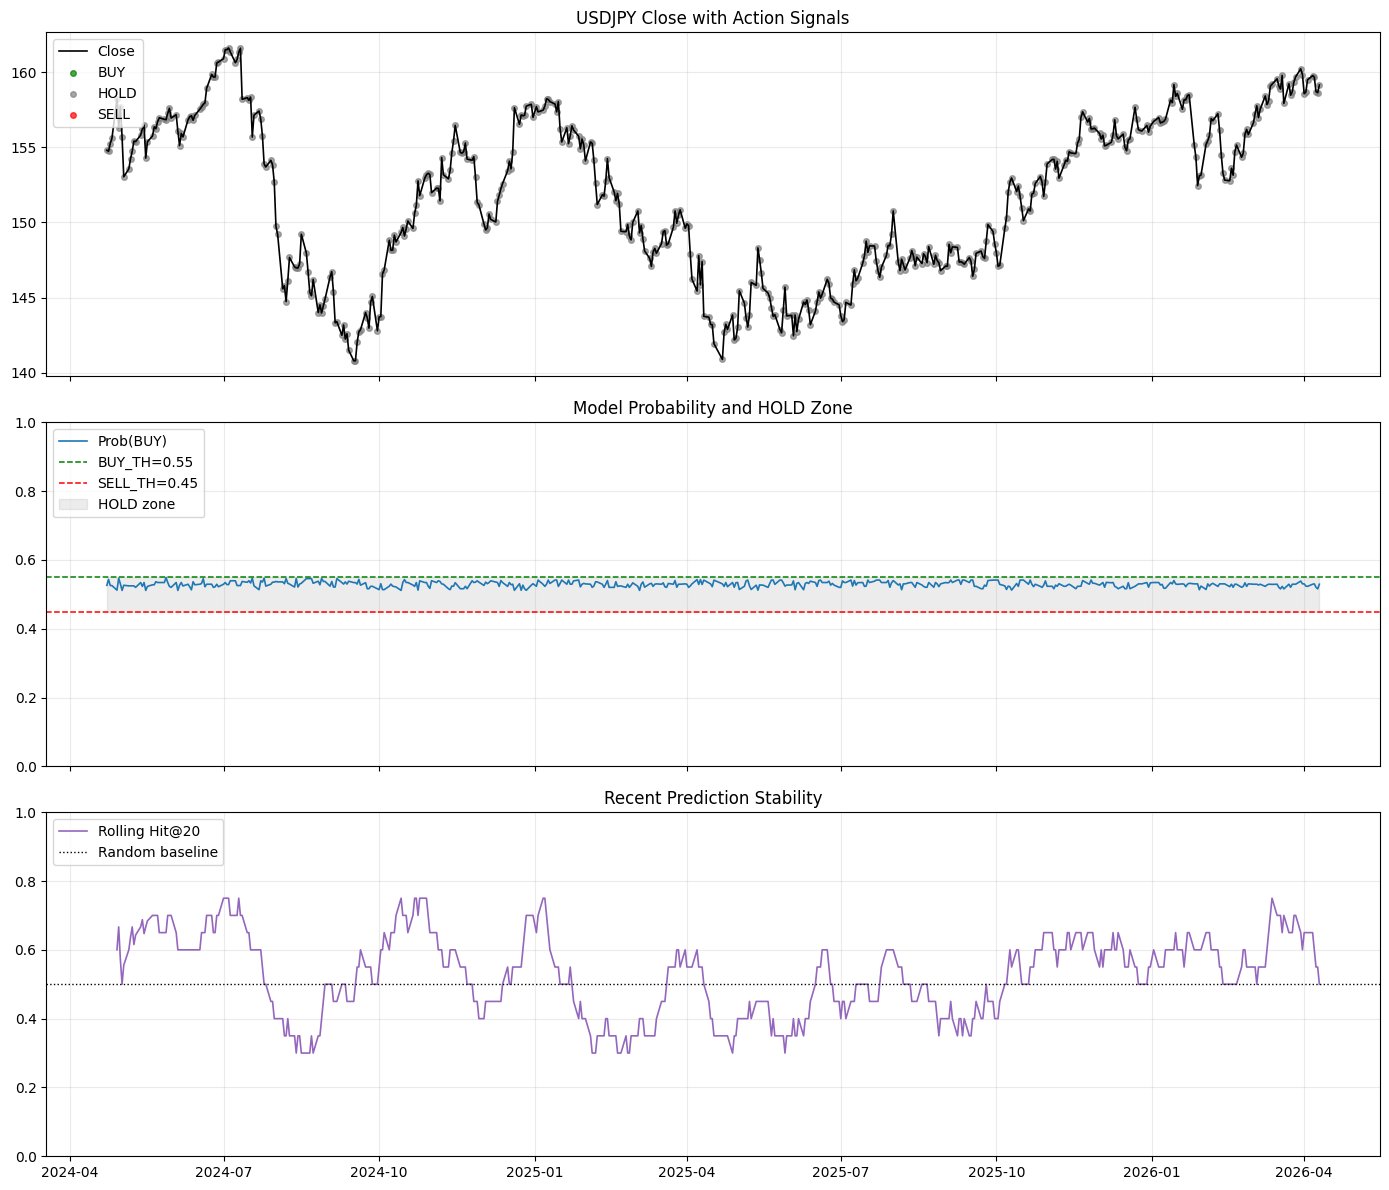

In [57]:
dashboard_df = valid_df.copy().reset_index().rename(columns={"index": "Date"})
dashboard_df["Date"] = pd.to_datetime(dashboard_df["Date"])
dashboard_df["prob_buy"] = proba_valid

dashboard_df["action"] = dashboard_df["prob_buy"].apply(
    lambda p: "BUY" if p >= BUY_THRESHOLD else ("SELL" if p <= SELL_THRESHOLD else "HOLD")
)

dashboard_df["pred_label_05"] = (dashboard_df["prob_buy"] >= 0.5).astype(int)
dashboard_df["hit_05"] = (dashboard_df["pred_label_05"].values == y_valid.values).astype(int)
dashboard_df["rolling_hit_20"] = dashboard_df["hit_05"].rolling(20, min_periods=5).mean()

# Calibration quality
brier = brier_score_loss(y_valid.values, dashboard_df["prob_buy"].values)
cal_score = np.clip(1 - (brier / 0.25), 0, 1)

# Recent hit quality
recent_hit = float(dashboard_df["rolling_hit_20"].dropna().iloc[-1]) if dashboard_df["rolling_hit_20"].notna().any() else 0.5

# Risk quality from strategy metrics
sharpe = float(trade_metrics.get("sharpe", 0.0))
max_dd = float(trade_metrics.get("max_drawdown", 0.0))
sharpe_score = np.clip((sharpe + 1.0) / 2.0, 0, 1)
dd_score = np.clip(1 - abs(max_dd) / 0.2, 0, 1)
risk_score = 0.5 * sharpe_score + 0.5 * dd_score

# Overall reliability score
reliability_score = 0.35 * cal_score + 0.25 * recent_hit + 0.25 * risk_score + 0.15 * np.clip(roc_auc_score(y_valid, proba_valid), 0, 1)

if reliability_score >= 0.70:
    reliability_label = "HIGH"
elif reliability_score >= 0.55:
    reliability_label = "MEDIUM"
else:
    reliability_label = "LOW"

latest = dashboard_df.iloc[-1]
print("=== Latest Decision Card ===")
print("Date:", latest["Date"].date())
print("Action:", latest["action"])
print("Prob BUY:", round(float(latest["prob_buy"]), 4))
print("Reliability:", reliability_label, f"({reliability_score:.3f})")
print("AUC:", round(roc_auc_score(y_valid, proba_valid), 4), "| Brier:", round(brier, 4))
print("RollingHit20:", round(recent_hit, 4), "| Sharpe:", round(sharpe, 4), "| MaxDD:", round(max_dd, 4))

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# 1) Price + action markers
axes[0].plot(dashboard_df["Date"], dashboard_df["Close"], color="black", linewidth=1.2, label="Close")
for action, color in [("BUY", "green"), ("HOLD", "gray"), ("SELL", "red")]:
    sub = dashboard_df[dashboard_df["action"] == action]
    axes[0].scatter(sub["Date"], sub["Close"], s=16, color=color, alpha=0.7, label=action)
axes[0].set_title("USDJPY Close with Action Signals")
axes[0].legend(loc="upper left")
axes[0].grid(alpha=0.25)

# 2) Probability + thresholds
axes[1].plot(dashboard_df["Date"], dashboard_df["prob_buy"], color="tab:blue", linewidth=1.2, label="Prob(BUY)")
axes[1].axhline(BUY_THRESHOLD, color="green", linestyle="--", linewidth=1.1, label=f"BUY_TH={BUY_THRESHOLD}")
axes[1].axhline(SELL_THRESHOLD, color="red", linestyle="--", linewidth=1.1, label=f"SELL_TH={SELL_THRESHOLD}")
axes[1].fill_between(dashboard_df["Date"], SELL_THRESHOLD, BUY_THRESHOLD, color="gray", alpha=0.15, label="HOLD zone")
axes[1].set_ylim(0, 1)
axes[1].set_title("Model Probability and HOLD Zone")
axes[1].legend(loc="upper left")
axes[1].grid(alpha=0.25)

# 3) Rolling hit rate
axes[2].plot(dashboard_df["Date"], dashboard_df["rolling_hit_20"], color="tab:purple", linewidth=1.2, label="Rolling Hit@20")
axes[2].axhline(0.5, color="black", linestyle=":", linewidth=1.0, label="Random baseline")
axes[2].set_ylim(0, 1)
axes[2].set_title("Recent Prediction Stability")
axes[2].legend(loc="upper left")
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 実績 + 直近7日予測の連結チャート

既存モデルで1日ずつ順方向に7日先まで予測し、実績終点から予測線を接続して表示します。
色分け:
- 実績: 青
- 予測ライン: オレンジ
- 予測アクション点: BUY=緑, HOLD=グレー, SELL=赤
- 実績と予測の接続: 黒点線

In [ ]:
from pandas.tseries.offsets import BDay

def build_7day_forward_forecast(raw_price_df, macro_df, model, feature_cols, horizon=7):
    sim_price = raw_price_df.copy()
    sim_macro = macro_df.copy()

    recent_vol = float(sim_price["Close"].pct_change().rolling(20).std().iloc[-1])
    if not np.isfinite(recent_vol) or recent_vol <= 0:
        recent_vol = 0.003

    rows = []
    for step in range(1, horizon + 1):
        feat_all, _ = build_features(sim_price, sim_macro)
        latest_feat = feat_all.iloc[[-1]].copy()
        prob_buy = float(model.predict_proba(latest_feat[feature_cols])[:, 1][0])
        action = to_action(prob_buy, BUY_THRESHOLD, SELL_THRESHOLD)

        # 確率から日次リターンを近似 (控えめにボラでスケール)
        edge = (prob_buy - 0.5) * 2.0
        pred_ret = float(np.clip(edge * recent_vol, -0.015, 0.015))

        prev_close = float(sim_price["Close"].iloc[-1])
        next_close = prev_close * (1.0 + pred_ret)

        next_date = pd.Timestamp(sim_price.index[-1]) + BDay(1)

        if "Volume" in sim_price.columns:
            next_volume = float(sim_price["Volume"].iloc[-1])
        else:
            next_volume = 0.0

        next_row = pd.DataFrame(
            {
                "Open": [prev_close],
                "High": [max(prev_close, next_close)],
                "Low": [min(prev_close, next_close)],
                "Close": [next_close],
                "Volume": [next_volume],
            },
            index=[next_date],
        )
        sim_price = pd.concat([sim_price, next_row])

        # マクロは最新値を持ち越し
        if len(sim_macro.columns) > 0:
            next_macro = pd.DataFrame([sim_macro.iloc[-1].values], index=[next_date], columns=sim_macro.columns)
            sim_macro = pd.concat([sim_macro, next_macro])

        rows.append(
            {
                "Date": next_date,
                "step": step,
                "prob_buy": prob_buy,
                "action": action,
                "pred_ret": pred_ret,
                "pred_close": next_close,
            }
        )

    return pd.DataFrame(rows)


forecast_7d_df = build_7day_forward_forecast(raw_df, macro_panel, model, feature_cols, horizon=7)

# 実績 + 予測の連結表示
history_window = 180
actual_plot = raw_df[["Close"]].copy().tail(history_window)

fig, ax = plt.subplots(figsize=(14, 6))

# 実績
ax.plot(actual_plot.index, actual_plot["Close"], color="tab:blue", linewidth=2.0, label="Actual USDJPY (Close)")

# 接続線 (実績最終点 -> 予測初日)
last_actual_date = actual_plot.index[-1]
last_actual_close = float(actual_plot["Close"].iloc[-1])
first_pred_date = pd.to_datetime(forecast_7d_df["Date"].iloc[0])
first_pred_close = float(forecast_7d_df["pred_close"].iloc[0])
ax.plot(
    [last_actual_date, first_pred_date],
    [last_actual_close, first_pred_close],
    color="black",
    linestyle=":",
    linewidth=1.4,
    label="Bridge",
)

# 予測ライン
ax.plot(
    pd.to_datetime(forecast_7d_df["Date"]),
    forecast_7d_df["pred_close"],
    color="tab:orange",
    linewidth=2.0,
    marker="o",
    label="7-Day Forecast",
)

# 予測アクション色分け
action_color = {"BUY": "green", "HOLD": "gray", "SELL": "red"}
for action, color in action_color.items():
    sub = forecast_7d_df[forecast_7d_df["action"] == action]
    if len(sub) == 0:
        continue
    ax.scatter(
        pd.to_datetime(sub["Date"]),
        sub["pred_close"],
        color=color,
        s=70,
        edgecolor="white",
        linewidth=0.8,
        zorder=5,
        label=f"Forecast {action}",
    )

ax.set_title("USDJPY: Actual + Connected 7-Day Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.grid(alpha=0.25)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

print("7-day forecast")
forecast_7d_df[["Date", "step", "prob_buy", "action", "pred_ret", "pred_close"]]

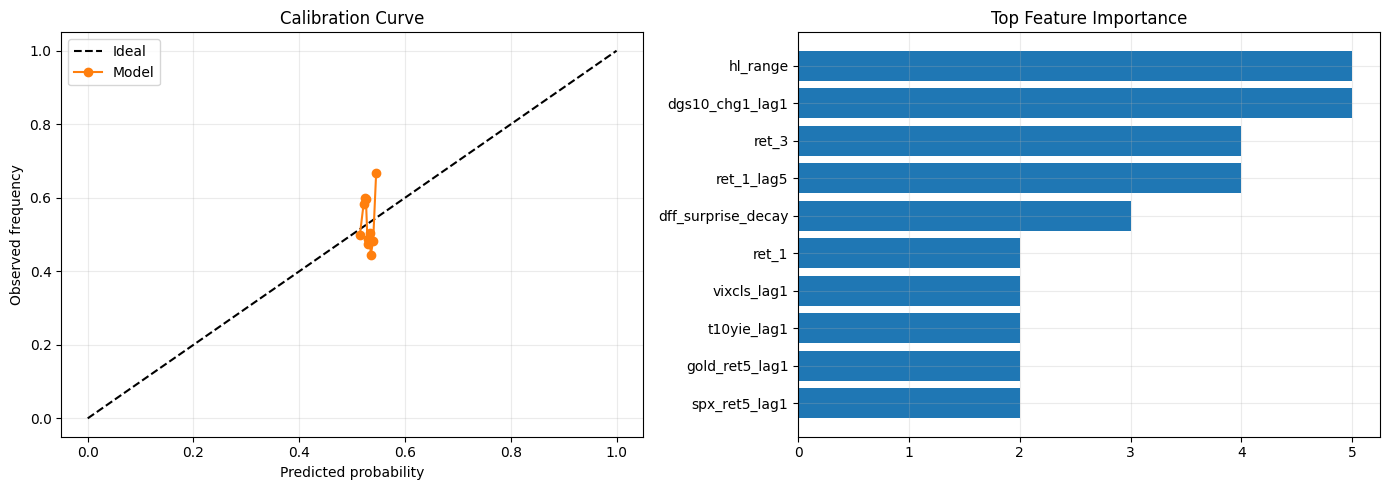

,feature,importance
12,hl_range,5
30,dgs10_chg1_lag1,5
1,ret_3,4
6,ret_1_lag5,4
51,dff_surprise_decay,3
0,ret_1,2
21,vixcls_lag1,2
20,t10yie_lag1,2
36,gold_ret5_lag1,2
38,spx_ret5_lag1,2


In [58]:
prob_true, prob_pred = calibration_curve(y_valid.values, proba_valid, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Calibration chart
ax[0].plot([0, 1], [0, 1], linestyle="--", color="black", label="Ideal")
ax[0].plot(prob_pred, prob_true, marker="o", color="tab:orange", label="Model")
ax[0].set_title("Calibration Curve")
ax[0].set_xlabel("Predicted probability")
ax[0].set_ylabel("Observed frequency")
ax[0].grid(alpha=0.25)
ax[0].legend(loc="upper left")

# Feature importance for explainability
if hasattr(model, "feature_importances_"):
    fi_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False).head(10)
else:
    fi_df = pd.DataFrame({"feature": feature_cols, "importance": np.nan})

ax[1].barh(fi_df["feature"][::-1], fi_df["importance"][::-1], color="tab:blue")
ax[1].set_title("Top Feature Importance")
ax[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

fi_df

In [59]:
def calc_atr(ohlc_df, period=ORDER_ATR_PERIOD):
    d = ohlc_df[["High", "Low", "Close"]].copy()
    prev_close = d["Close"].shift(1)
    tr = pd.concat([
        d["High"] - d["Low"],
        (d["High"] - prev_close).abs(),
        (d["Low"] - prev_close).abs(),
    ], axis=1).max(axis=1)
    return tr.rolling(period, min_periods=period).mean()


def _round_px(x):
    return round(float(x), ORDER_PRICE_ROUND)


def _apply_manual_price_overrides(payload, entry_price=None, tp_price=None, sl_price=None):
    out = dict(payload)

    def _set_if(v):
        return _round_px(v) if v is not None else None

    e = _set_if(entry_price)
    tp = _set_if(tp_price)
    sl = _set_if(sl_price)

    if e is not None:
        if "entry" in out:
            out["entry"] = e
        if "parent" in out and isinstance(out["parent"], dict) and "entry" in out["parent"]:
            out["parent"] = dict(out["parent"]); out["parent"]["entry"] = e
        if "legs" in out and isinstance(out["legs"], list) and len(out["legs"]) > 0:
            out["legs"] = [dict(c) for c in out["legs"]]
            out["legs"][0]["entry"] = e

    if tp is not None:
        if "take_profit" in out:
            out["take_profit"] = tp
        if "child" in out and isinstance(out["child"], dict) and out["child"].get("type") == "TAKE_PROFIT":
            out["child"] = dict(out["child"]); out["child"]["price"] = tp
        if "children" in out and isinstance(out["children"], list):
            out["children"] = [dict(c) for c in out["children"]]
            for c in out["children"]:
                if c.get("type") == "TAKE_PROFIT":
                    c["price"] = tp

    if sl is not None:
        if "stop_loss" in out:
            out["stop_loss"] = sl
        if "children" in out and isinstance(out["children"], list):
            out["children"] = [dict(c) for c in out["children"]]
            for c in out["children"]:
                if c.get("type") == "STOP_LOSS":
                    c["price"] = sl

    return out


def build_order_template(order_type, side, ref_price, atr):
    sign = 1 if side == "BUY" else -1
    entry_limit = ref_price - sign * ORDER_ENTRY_OFFSET_ATR * atr
    entry_stop = ref_price + sign * ORDER_ENTRY_OFFSET_ATR * atr
    tp_ref = ref_price + sign * ORDER_TP_ATR_MULT * atr
    sl_ref = ref_price - sign * ORDER_SL_ATR_MULT * atr
    tp_limit = entry_limit + sign * ORDER_TP_ATR_MULT * atr
    sl_limit = entry_limit - sign * ORDER_SL_ATR_MULT * atr
    tp_stop = entry_stop + sign * ORDER_TP_ATR_MULT * atr
    sl_stop = entry_stop - sign * ORDER_SL_ATR_MULT * atr

    if order_type == "MARKET":
        return {"type": "MARKET", "side": side, "entry": _round_px(ref_price), "take_profit": _round_px(tp_ref), "stop_loss": _round_px(sl_ref)}
    if order_type == "LIMIT":
        return {"type": "LIMIT", "side": side, "entry": _round_px(entry_limit), "take_profit": _round_px(tp_limit), "stop_loss": _round_px(sl_limit)}
    if order_type == "STOP":
        return {"type": "STOP", "side": side, "entry": _round_px(entry_stop), "take_profit": _round_px(tp_stop), "stop_loss": _round_px(sl_stop)}
    if order_type == "IFD":
        return {"type": "IFD", "parent": {"type": "LIMIT", "side": side, "entry": _round_px(entry_limit)}, "child": {"type": "TAKE_PROFIT", "price": _round_px(tp_limit)}, "stop_loss": _round_px(sl_limit)}
    if order_type == "OCO":
        return {"type": "OCO", "legs": [{"type": "LIMIT", "side": side, "entry": _round_px(entry_limit)}, {"type": "STOP", "side": side, "entry": _round_px(entry_stop)}], "cancel_rule": "first_filled_cancels_other"}
    if order_type == "IFDOCO":
        return {"type": "IFDOCO", "parent": {"type": "LIMIT", "side": side, "entry": _round_px(entry_limit)}, "children": [{"type": "TAKE_PROFIT", "price": _round_px(tp_limit)}, {"type": "STOP_LOSS", "price": _round_px(sl_limit)}], "cancel_rule": "one_child_filled_cancels_other"}
    return {"type": "NO_ORDER"}


def select_order_type(action, reliability_label, prob_buy):
    if action == "HOLD":
        return "NO_ORDER", []
    confidence = abs(float(prob_buy) - 0.5)
    allowed_map = {
        "LOW": ["MARKET", "LIMIT", "STOP"],
        "MEDIUM": ["MARKET", "LIMIT", "STOP", "IFD", "OCO"],
        "HIGH": ["MARKET", "LIMIT", "STOP", "IFD", "OCO", "IFDOCO"],
    }
    candidates = allowed_map.get(reliability_label, ["MARKET", "LIMIT", "STOP"])

    if reliability_label == "HIGH":
        selected = "IFDOCO" if confidence >= 0.08 else "OCO"
    elif reliability_label == "MEDIUM":
        selected = "IFD" if confidence >= 0.06 else "LIMIT"
    else:
        selected = "MARKET" if confidence >= 0.08 else "STOP"
    if selected not in candidates:
        selected = candidates[0]
    return selected, candidates


def suggest_order_plan(latest_row, reliability_label, reliability_score, raw_price_df):
    action = str(latest_row["action"])

    prob_buy = float(latest_row["prob_buy"])

    latest_date = pd.to_datetime(latest_row["Date"])

    hist = raw_price_df.loc[raw_price_df.index <= latest_date].copy()
    atr_series = calc_atr(hist, period=ORDER_ATR_PERIOD)
    atr = float(atr_series.iloc[-1]) if atr_series.notna().any() else np.nan
    ref_price = float(latest_row["Close"])

    manual_mode = str(ORDER_SELECTION_MODE).lower() == "manual"

    if manual_mode:
        side = str(MANUAL_ORDER_SIDE).upper()
        selected_type = str(MANUAL_ORDER_TYPE).upper()
        candidates = [selected_type]
        payload = build_order_template(selected_type, side, ref_price, atr)
        payload = _apply_manual_price_overrides(payload, MANUAL_ENTRY_PRICE, MANUAL_TP_PRICE, MANUAL_SL_PRICE)
    else:
        if action == "HOLD":
            return {
                "selected_type": "NO_ORDER",
                "candidates": [],
                "side": "HOLD",
                "atr_14": np.nan,
                "entry_price": np.nan,
                "entry_price_alt": np.nan,
                "take_profit_price": np.nan,
                "stop_loss_price": np.nan,
                "order_payload": {"type": "NO_ORDER", "reason": "action_is_hold"},
                "reliability_score": float(reliability_score),
                "selection_mode": ORDER_SELECTION_MODE,
            }
        side = "BUY" if action == "BUY" else "SELL"
        selected_type, candidates = select_order_type(action, reliability_label, prob_buy)
        payload = build_order_template(selected_type, side, ref_price, atr)

    entry = payload.get("entry", np.nan)
    entry_alt = np.nan
    tp = payload.get("take_profit", np.nan)
    sl = payload.get("stop_loss", np.nan)
    if pd.isna(entry) and "parent" in payload and "entry" in payload["parent"]:
        entry = payload["parent"]["entry"]
    if pd.isna(entry) and "legs" in payload and len(payload["legs"]) > 0:
        entry = payload["legs"][0].get("entry", np.nan)
        if len(payload["legs"]) > 1:
            entry_alt = payload["legs"][1].get("entry", np.nan)
    if pd.isna(tp) and "child" in payload and payload["child"].get("type") == "TAKE_PROFIT":
        tp = payload["child"].get("price", np.nan)
    if pd.isna(tp) and "children" in payload:
        for c in payload["children"]:
            if c.get("type") == "TAKE_PROFIT":
                tp = c.get("price", np.nan)
    if pd.isna(sl) and "children" in payload:
        for c in payload["children"]:
            if c.get("type") == "STOP_LOSS":
                sl = c.get("price", np.nan)
    if pd.isna(sl) and "stop_loss" in payload:
        sl = payload.get("stop_loss", np.nan)

    return {
        "selected_type": selected_type,
        "candidates": candidates,
        "side": side,
        "atr_14": _round_px(atr) if pd.notna(atr) else np.nan,
        "entry_price": float(entry) if pd.notna(entry) else np.nan,
        "entry_price_alt": float(entry_alt) if pd.notna(entry_alt) else np.nan,
        "take_profit_price": float(tp) if pd.notna(tp) else np.nan,
        "stop_loss_price": float(sl) if pd.notna(sl) else np.nan,
        "order_payload": payload,
        "reliability_score": float(reliability_score),
        "selection_mode": ORDER_SELECTION_MODE,
    }


order_plan = suggest_order_plan(latest, reliability_label, reliability_score, raw_df)
print("=== Order Suggestion ===")
print("mode:", order_plan["selection_mode"])
print("type:", order_plan["selected_type"])
print("candidates:", order_plan["candidates"])
print("side:", order_plan["side"])
print("entry/tp/sl:", order_plan["entry_price"], order_plan["take_profit_price"], order_plan["stop_loss_price"])
print("entry_alt(oco):", order_plan["entry_price_alt"])
print("atr_14:", order_plan["atr_14"])
order_plan

=== Order Suggestion ===
mode: auto
type: NO_ORDER
candidates: []
side: HOLD
entry/tp/sl: nan nan nan
entry_alt(oco): nan
atr_14: nan


{'selected_type': 'NO_ORDER',
 'candidates': [],
 'side': 'HOLD',
 'atr_14': nan,
 'entry_price': nan,
 'entry_price_alt': nan,
 'take_profit_price': nan,
 'stop_loss_price': nan,
 'order_payload': {'type': 'NO_ORDER', 'reason': 'action_is_hold'},
 'reliability_score': 0.38452220534599807,
 'selection_mode': 'auto'}

In [60]:
# Preview all order methods with ATR-based prices on latest bar
latest_date = pd.to_datetime(latest["Date"])

hist = raw_df.loc[raw_df.index <= latest_date].copy()
atr_val = float(calc_atr(hist, period=ORDER_ATR_PERIOD).dropna().iloc[-1])
ref_price = float(latest["Close"])

preview_rows = []
for side in ["BUY", "SELL"]:
    for method in ["MARKET", "LIMIT", "STOP", "IFD", "OCO", "IFDOCO"]:
        payload = build_order_template(method, side, ref_price, atr_val)
        payload = _apply_manual_price_overrides(payload, MANUAL_ENTRY_PRICE, MANUAL_TP_PRICE, MANUAL_SL_PRICE)

        entry = payload.get("entry", np.nan)
        entry_alt = np.nan
        tp = payload.get("take_profit", np.nan)
        sl = payload.get("stop_loss", np.nan)
        if pd.isna(entry) and "parent" in payload and "entry" in payload["parent"]:
            entry = payload["parent"]["entry"]
        if pd.isna(entry) and "legs" in payload and len(payload["legs"]) > 0:
            entry = payload["legs"][0].get("entry", np.nan)
            if len(payload["legs"]) > 1:
                entry_alt = payload["legs"][1].get("entry", np.nan)
        if pd.isna(tp) and "child" in payload and payload["child"].get("type") == "TAKE_PROFIT":
            tp = payload["child"].get("price", np.nan)
        if pd.isna(tp) and "children" in payload:
            for c in payload["children"]:
                if c.get("type") == "TAKE_PROFIT":
                    tp = c.get("price", np.nan)
        if pd.isna(sl) and "children" in payload:
            for c in payload["children"]:
                if c.get("type") == "STOP_LOSS":
                    sl = c.get("price", np.nan)
        if pd.isna(sl) and "stop_loss" in payload:
            sl = payload.get("stop_loss", np.nan)

        preview_rows.append({
            "side": side,
            "method": method,
            "ref_price": _round_px(ref_price),
            "atr_14": _round_px(atr_val),
            "entry": entry,
            "entry_alt": entry_alt,
            "take_profit": tp,
            "stop_loss": sl,
        })

order_method_preview_df = pd.DataFrame(preview_rows)
order_method_preview_df

,side,method,ref_price,atr_14,entry,entry_alt,take_profit,stop_loss
0,BUY,MARKET,159.157,0.963,159.157,NaN,160.602,158.194
1,BUY,LIMIT,159.157,0.963,158.916,NaN,160.361,157.953
2,BUY,STOP,159.157,0.963,159.398,NaN,160.843,158.435
3,BUY,IFD,159.157,0.963,158.916,NaN,160.361,157.953
4,BUY,OCO,159.157,0.963,158.916,159.398,NaN,NaN
5,BUY,IFDOCO,159.157,0.963,158.916,NaN,160.361,157.953
6,SELL,MARKET,159.157,0.963,159.157,NaN,157.712,160.120
7,SELL,LIMIT,159.157,0.963,159.398,NaN,157.953,160.361
8,SELL,STOP,159.157,0.963,158.916,NaN,157.471,159.879
9,SELL,IFD,159.157,0.963,159.398,NaN,157.953,160.361


In [61]:
MEMO_PATH = DATA_DIR / "decision_memo.csv"

memo_cols = [
    "date", "model_action", "prob_buy", "reliability_label", "reliability_score",
    "order_type", "order_side", "entry_price", "entry_price_alt", "take_profit_price", "stop_loss_price", "atr_14", "order_payload",
    "user_action", "reason_category", "reason_note", "result_after_1d"
]

if MEMO_PATH.exists():
    memo_df = pd.read_csv(MEMO_PATH)
else:
    memo_df = pd.DataFrame(columns=memo_cols)

new_template = {
    "date": str(latest["Date"].date()),
    "model_action": latest["action"],
    "prob_buy": round(float(latest["prob_buy"]), 4),
    "reliability_label": reliability_label,
    "reliability_score": round(float(reliability_score), 4),
    "order_type": order_plan["selected_type"],
    "order_side": order_plan["side"],
    "entry_price": order_plan["entry_price"],
    "entry_price_alt": order_plan["entry_price_alt"],
    "take_profit_price": order_plan["take_profit_price"],
    "stop_loss_price": order_plan["stop_loss_price"],
    "atr_14": order_plan["atr_14"],
    "order_payload": json.dumps(order_plan["order_payload"], ensure_ascii=False),
    "user_action": "",  # ここに自分の判断を入力
    "reason_category": "",  # 例: news / technical / intuition
    "reason_note": "",
    "result_after_1d": "",  # 翌日結果を後で記録
}

preview_df = pd.DataFrame([new_template])
print("Memo file:", MEMO_PATH.resolve())
print("Write your decision by filling preview row and append when ready.")
preview_df

Memo file: /Users/tsukasahamaoka/Document/DS_Projects/2_PR,TS_FX forcast/data/decision_memo.csv
Write your decision by filling preview row and append when ready.


,date,model_action,prob_buy,reliability_label,reliability_score,order_type,order_side,entry_price,entry_price_alt,take_profit_price,stop_loss_price,atr_14,order_payload,user_action,reason_category,reason_note,result_after_1d
0,2026-04-10,HOLD,0.5293,LOW,0.3845,NO_ORDER,HOLD,NaN,NaN,NaN,NaN,NaN,"{""type"": ""NO_ORDER"", ""reason"": ""action_is_hold""}",,,,


In [62]:
def append_decision_memo(
    user_action,
    reason_category,
    reason_note,
    result_after_1d="",
    memo_path=MEMO_PATH,
):
    row = {
        "date": str(latest["Date"].date()),
        "model_action": latest["action"],
        "prob_buy": round(float(latest["prob_buy"]), 4),
        "reliability_label": reliability_label,
        "reliability_score": round(float(reliability_score), 4),
        "order_type": order_plan["selected_type"],
        "order_side": order_plan["side"],
        "entry_price": order_plan["entry_price"],
        "entry_price_alt": order_plan["entry_price_alt"],
        "take_profit_price": order_plan["take_profit_price"],
        "stop_loss_price": order_plan["stop_loss_price"],
        "atr_14": order_plan["atr_14"],
        "order_payload": json.dumps(order_plan["order_payload"], ensure_ascii=False),
        "user_action": user_action,
        "reason_category": reason_category,
        "reason_note": reason_note,
        "result_after_1d": result_after_1d,
    }

    if memo_path.exists():
        df = pd.read_csv(memo_path)
    else:
        df = pd.DataFrame(columns=list(row.keys()))

    df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    df.to_csv(memo_path, index=False)
    return df.tail(5)

# Example (uncomment to save):
# append_decision_memo(
#     user_action="HOLD",
#     reason_category="technical",
#     reason_note="Model confidence in HOLD zone, no clear edge.",
# )